# Network Analysis: Node Degrees and Bipartite Graphs by Community

This notebook analyzes network data to:
1. Calculate node degrees based on edge connections
2. Identify the 10 most and least connected nodes in each community
3. Visualize bipartite graphs for communities 0, 1, 2, 3, 4 based on the "set" attribute

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from networkx.algorithms import bipartite
import seaborn as sns

# Set style for better visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (15, 10)

In [12]:
# Load the data
nodes_df = pd.read_csv('../data/processed/us/nodes.csv')
edges_df = pd.read_csv('../data/processed/us/edges.csv')

print(f"Nodes shape: {nodes_df.shape}")
print(f"Edges shape: {edges_df.shape}")
print(f"\nNumber of unique communities: {nodes_df['community_id'].nunique()}")
print(f"\nNodes DataFrame columns: {nodes_df.columns.tolist()}")
print(f"Edges DataFrame columns: {edges_df.columns.tolist()}")

Nodes shape: (15347, 7)
Edges shape: (156481, 24)

Number of unique communities: 171

Nodes DataFrame columns: ['index', 'index.1', 'community_id', 'node', 'community_size', 'id', 'set']
Edges DataFrame columns: ['index', 'investor_name_left', 'investor_name_right', 'announced_year_left', 'announced_year_right', 'org_uuid', 'total_funding_usd', 'total_funding_usd_left', 'total_funding_usd_right', 'year', 'company_country', 'investor_country_left', 'investor_country_right', 'investor_region_left', 'investor_region_right', 'investment_type_left', 'investment_type_right', 'category_left', 'category_right', 'community_left', 'community_right', 'community', 'Source', 'Target']


In [13]:
# Display sample data
print("Sample Nodes Data:")
print(nodes_df.head())
print("\n" + "="*80 + "\n")
print("Sample Edges Data:")
print(edges_df.head())

Sample Nodes Data:
   index  index.1  community_id                          node  community_size  \
0      0        0             0  Ironspring Ventures-series_a            4212   
1      1        1             0                 Bolt-series_a            4212   
2      2        2             0          NightDragon-series_e            4212   
3      3        3             0                Xfund-series_e            4212   
4      4        4             0   Borderless Capital-series_b            4212   

                             id  set  
0  Ironspring Ventures-series_a    1  
1                 Bolt-series_a    1  
2          NightDragon-series_e    0  
3                Xfund-series_e    0  
4   Borderless Capital-series_b    0  


Sample Edges Data:
   index  investor_name_left         investor_name_right  announced_year_left  \
0      0  Benchmark-series_c              Accel-series_a                 2007   
1      2  Benchmark-series_c    Sequoia Capital-series_a                 2007

## Step 1: Calculate Node Degrees

Calculate the degree (number of connections) for each node based on the edges data.

In [14]:
# Calculate degree for each node by counting occurrences in Source and Target columns
source_degrees = edges_df['Source'].value_counts()
target_degrees = edges_df['Target'].value_counts()

# Combine degrees (a node can appear as both source and target)
all_degrees = pd.concat([source_degrees, target_degrees]).groupby(level=0).sum()

# Create a dataframe with degrees
degree_df = pd.DataFrame({
    'node': all_degrees.index,
    'degree': all_degrees.values
})

print(f"Number of nodes with calculated degrees: {len(degree_df)}")
print(f"\nDegree statistics:")
print(degree_df['degree'].describe())
print(f"\nTop 10 nodes by degree:")
print(degree_df.nlargest(10, 'degree'))

Number of nodes with calculated degrees: 15347

Degree statistics:
count    15347.000000
mean        20.392389
std         45.146593
min          1.000000
25%          4.000000
50%          8.000000
75%         19.500000
max       1436.000000
Name: degree, dtype: float64

Top 10 nodes by degree:
                                     node  degree
11683                       SV Angel-seed    1436
11684                   SV Angel-series_a    1057
7638             Khosla Ventures-series_a     819
1037         Andreessen Horowitz-series_a     816
9419   New Enterprise Associates-series_a     725
13265                      Techstars-seed     685
12048            Sequoia Capital-series_a     683
923              Alumni Ventures-series_b     666
5545                    Gaingels-series_b     665
462                        Accel-series_a     656


In [15]:
# Merge degree information with nodes dataframe
nodes_with_degree = nodes_df.merge(degree_df, on='node', how='left')

# Fill NaN degrees with 0 (for nodes that don't appear in edges)
nodes_with_degree['degree'] = nodes_with_degree['degree'].fillna(0).astype(int)

print(f"Nodes with degree data shape: {nodes_with_degree.shape}")
print(f"\nSample of nodes with degrees:")
print(nodes_with_degree[['node', 'community_id', 'set', 'degree']].head(10))
print(f"\nNodes with 0 degree: {(nodes_with_degree['degree'] == 0).sum()}")

Nodes with degree data shape: (15347, 8)

Sample of nodes with degrees:
                                  node  community_id  set  degree
0         Ironspring Ventures-series_a             0    1      14
1                        Bolt-series_a             0    1      34
2                 NightDragon-series_e             0    0      16
3                       Xfund-series_e             0    0      12
4          Borderless Capital-series_b             0    0      21
5            Blueprint Equity-series_a             0    1       1
6  Hyde Park Venture Partners-series_b             0    0      27
7                 GOS Capital-series_b             0    0       8
8             Voyager Capital-series_b             0    0      29
9                 Builders VC-series_a             0    1      32

Nodes with 0 degree: 0


## Step 2: Identify Top 10 Most and Least Connected Nodes per Community

For each community, we'll identify the 10 most connected and 10 least connected nodes.

In [16]:
# Function to get top and bottom nodes for each community
def get_top_bottom_nodes(df, community_id, n=10):
    """
    Get top n and bottom n nodes by degree for a given community
    """
    community_nodes = df[df['community_id'] == community_id].copy()
    
    # Sort by degree
    community_nodes_sorted = community_nodes.sort_values('degree', ascending=False)
    
    # Get top n
    top_n = community_nodes_sorted.head(n)
    
    # Get bottom n
    bottom_n = community_nodes_sorted.tail(n)
    
    return top_n, bottom_n

# Get summary statistics for each community
community_stats = []

for community_id in nodes_with_degree['community_id'].unique():
    community_data = nodes_with_degree[nodes_with_degree['community_id'] == community_id]
    
    stats = {
        'community_id': community_id,
        'total_nodes': len(community_data),
        'set_0_nodes': (community_data['set'] == 0).sum(),
        'set_1_nodes': (community_data['set'] == 1).sum(),
        'avg_degree': community_data['degree'].mean(),
        'max_degree': community_data['degree'].max(),
        'min_degree': community_data['degree'].min()
    }
    community_stats.append(stats)

community_stats_df = pd.DataFrame(community_stats).sort_values('community_id')
print("Community Statistics for Communities 0-4:")
print(community_stats_df[community_stats_df['community_id'].isin([0, 1, 2, 3, 4])])

Community Statistics for Communities 0-4:
   community_id  total_nodes  set_0_nodes  set_1_nodes  avg_degree  \
0             0         4212         2280         1932   22.778965   
1             1         4062         2571         1491   12.172575   
2             2         4040         2910         1130   35.592327   
3             3          928          577          351    9.782328   
4             4          372          214          158   12.198925   

   max_degree  min_degree  
0         685           1  
1         274           1  
2        1436           1  
3         101           1  
4          88           1  


## Step 3: Create Bipartite Graphs for Communities 0-4

Visualize bipartite graphs showing the most and least connected nodes, with nodes separated by their "set" value (0 or 1) and showing actual network connections.

In [ ]:
def create_combined_bipartite_graph(top_nodes, bottom_nodes, top_edges, bottom_edges, community_id):
    """
    Create a bipartite graph showing both most and least connected nodes together
    
    Parameters:
    - top_nodes: DataFrame of most connected nodes
    - bottom_nodes: DataFrame of least connected nodes
    - top_edges: DataFrame of edges between top nodes
    - bottom_edges: DataFrame of edges between bottom nodes
    - community_id: ID of the community
    """
    # Create a graph
    G = nx.Graph()
    
    # Add all nodes (top and bottom) with bipartite set attribute
    for _, node_row in pd.concat([top_nodes, bottom_nodes]).iterrows():
        node_type = 'most_connected' if node_row['node'] in top_nodes['node'].values else 'least_connected'
        G.add_node(node_row['node'], 
                   bipartite=node_row['set'],
                   degree=node_row['degree'],
                   node_type=node_type)
    
    # Add all edges (from both top and bottom)
    for _, edge_row in pd.concat([top_edges, bottom_edges]).iterrows():
        if edge_row['Source'] in G.nodes() and edge_row['Target'] in G.nodes():
            G.add_edge(edge_row['Source'], edge_row['Target'])
    
    # Separate nodes by set
    set_0_nodes = [n for n, d in G.nodes(data=True) if d.get('bipartite', 0) == 0]
    set_1_nodes = [n for n, d in G.nodes(data=True) if d.get('bipartite', 0) == 1]
    
    if len(set_0_nodes) == 0 or len(set_1_nodes) == 0:
        print(f"Warning: Community {community_id} doesn't have nodes in both sets")
        print(f"Set 0: {len(set_0_nodes)}, Set 1: {len(set_1_nodes)}")
        return None
    
    # Separate by node type for coloring
    top_set_0 = [n for n in set_0_nodes if G.nodes[n]['node_type'] == 'most_connected']
    top_set_1 = [n for n in set_1_nodes if G.nodes[n]['node_type'] == 'most_connected']
    bottom_set_0 = [n for n in set_0_nodes if G.nodes[n]['node_type'] == 'least_connected']
    bottom_set_1 = [n for n in set_1_nodes if G.nodes[n]['node_type'] == 'least_connected']
    
    # Use bipartite layout
    pos = nx.bipartite_layout(G, set_0_nodes, align='vertical', scale=2)
    
    # Create visualization
    fig, ax = plt.subplots(figsize=(22, 14))
    
    # Draw most connected nodes from Set 0 (left side)
    if len(top_set_0) > 0:
        nx.draw_networkx_nodes(G, pos, 
                              nodelist=top_set_0,
                              node_color='#2980b9',  # Dark blue
                              node_size=[G.nodes[node].get('degree', 1) * 50 for node in top_set_0],
                              alpha=0.9,
                              label='Set 0 - Most Connected')
    
    # Draw most connected nodes from Set 1 (right side)
    if len(top_set_1) > 0:
        nx.draw_networkx_nodes(G, pos,
                              nodelist=top_set_1,
                              node_color='#c0392b',  # Dark red
                              node_size=[G.nodes[node].get('degree', 1) * 50 for node in top_set_1],
                              alpha=0.9,
                              label='Set 1 - Most Connected')
    
    # Draw least connected nodes from Set 0 (left side)
    if len(bottom_set_0) > 0:
        nx.draw_networkx_nodes(G, pos,
                              nodelist=bottom_set_0,
                              node_color='#85c1e9',  # Light blue
                              node_size=[G.nodes[node].get('degree', 1) * 50 for node in bottom_set_0],
                              alpha=0.7,
                              label='Set 0 - Least Connected')
    
    # Draw least connected nodes from Set 1 (right side)
    if len(bottom_set_1) > 0:
        nx.draw_networkx_nodes(G, pos,
                              nodelist=bottom_set_1,
                              node_color='#f1948a',  # Light red
                              node_size=[G.nodes[node].get('degree', 1) * 50 for node in bottom_set_1],
                              alpha=0.7,
                              label='Set 1 - Least Connected')
    
    # Draw edges
    nx.draw_networkx_edges(G, pos, alpha=0.15, width=1.5, edge_color='gray')
    
    # Draw labels
    labels = {node: node.split('-')[0][:20] for node in G.nodes()}
    nx.draw_networkx_labels(G, pos, labels, font_size=7, font_weight='bold')
    
    plt.title(f'Bipartite Graph - Community {community_id}\n'
              f'Showing Top 10 Most Connected and Top 10 Least Connected Nodes\n'
              f'Set 0: {len(set_0_nodes)} nodes | Set 1: {len(set_1_nodes)} nodes | '
              f'Total Edges: {G.number_of_edges()}',
              fontsize=16, fontweight='bold', pad=20)
    plt.legend(loc='upper right', fontsize=11, framealpha=0.9)
    plt.axis('off')
    plt.tight_layout()
    
    return G


Processing Community 0

Top 10 nodes - Set distribution: Set 0: 4, Set 1: 6
Edges between top nodes: 60

Bottom 10 nodes - Set distribution: Set 0: 8, Set 1: 2
Edges between bottom nodes: 0

--- Most Connected Nodes ---


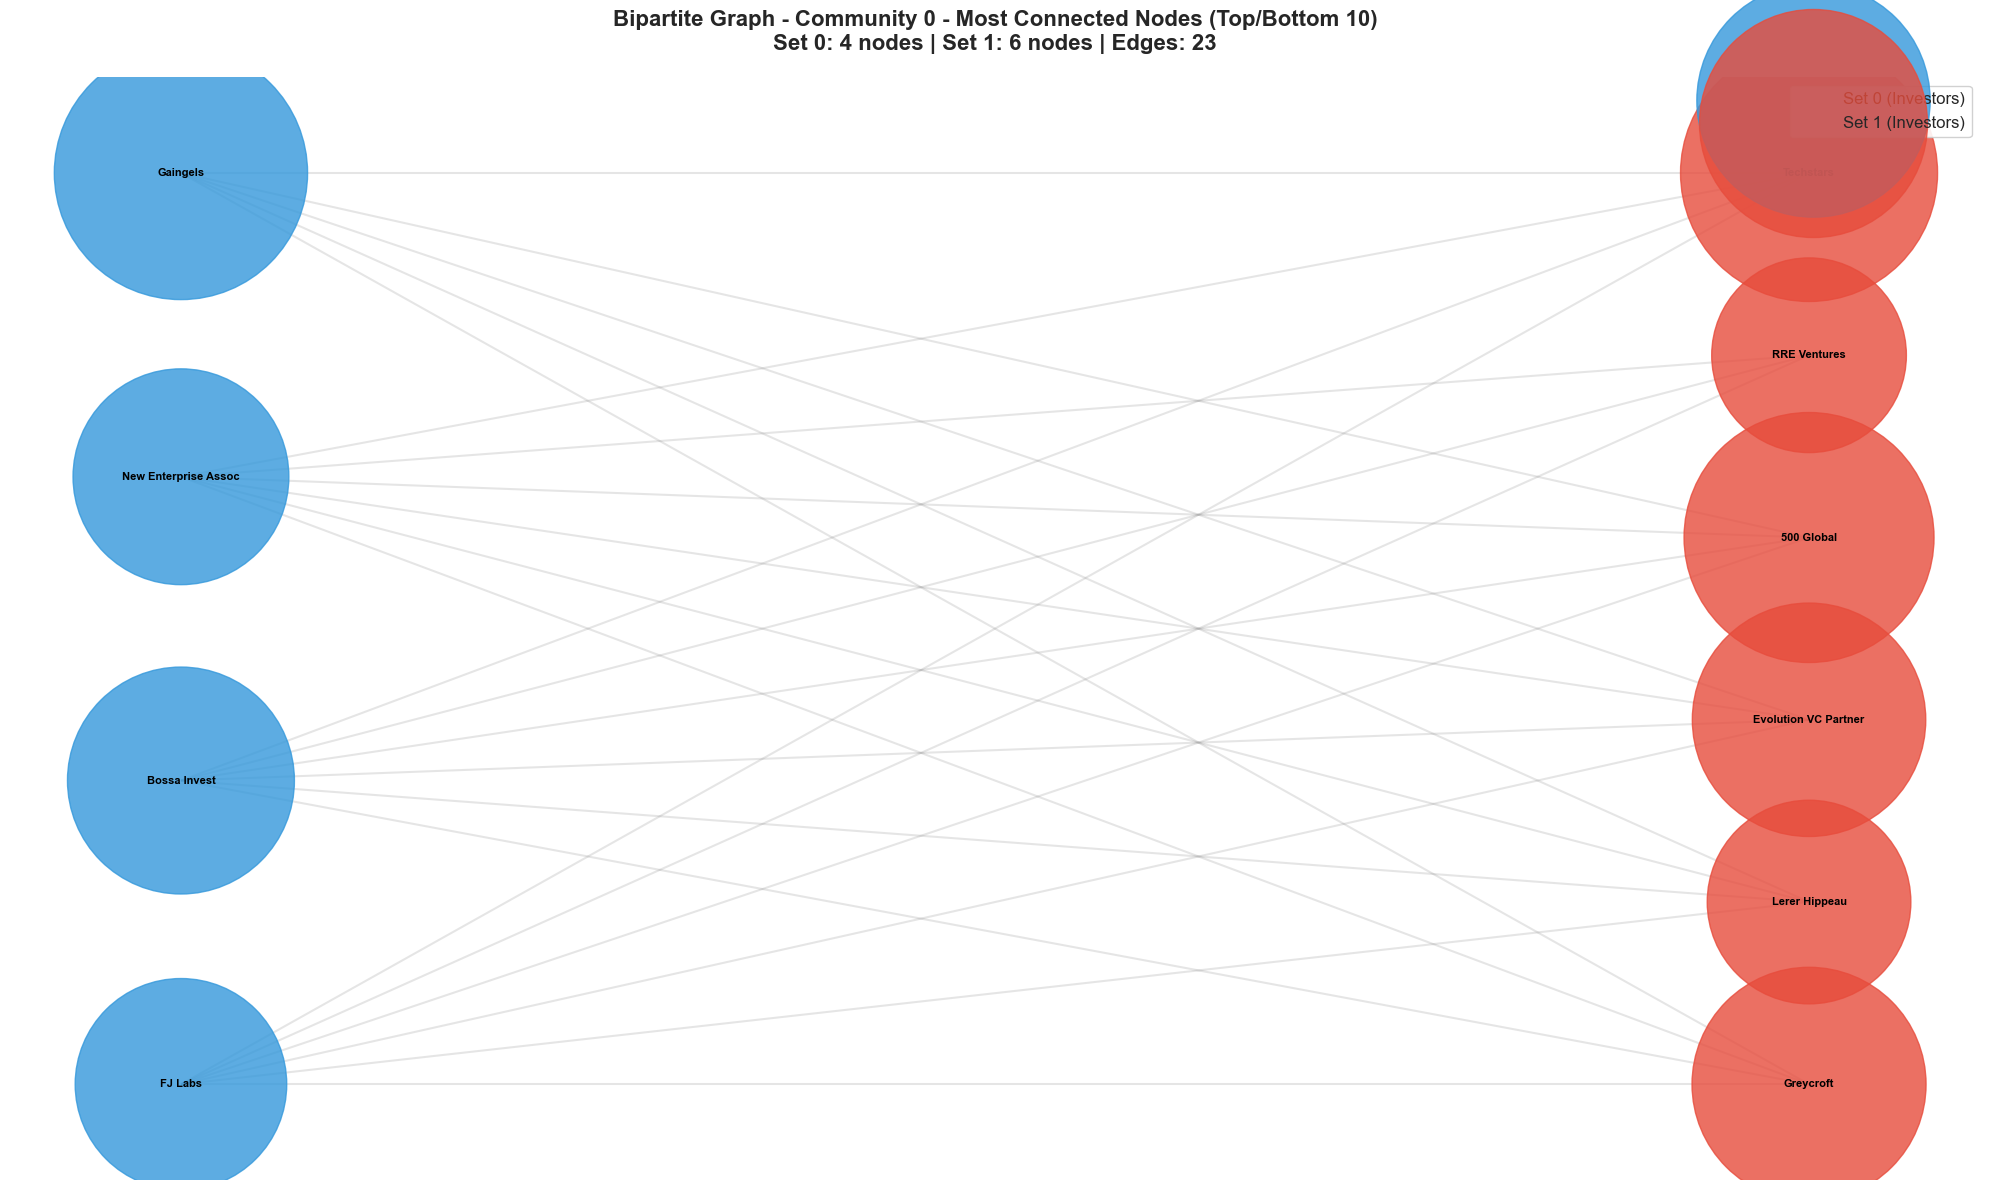


--- Least Connected Nodes ---


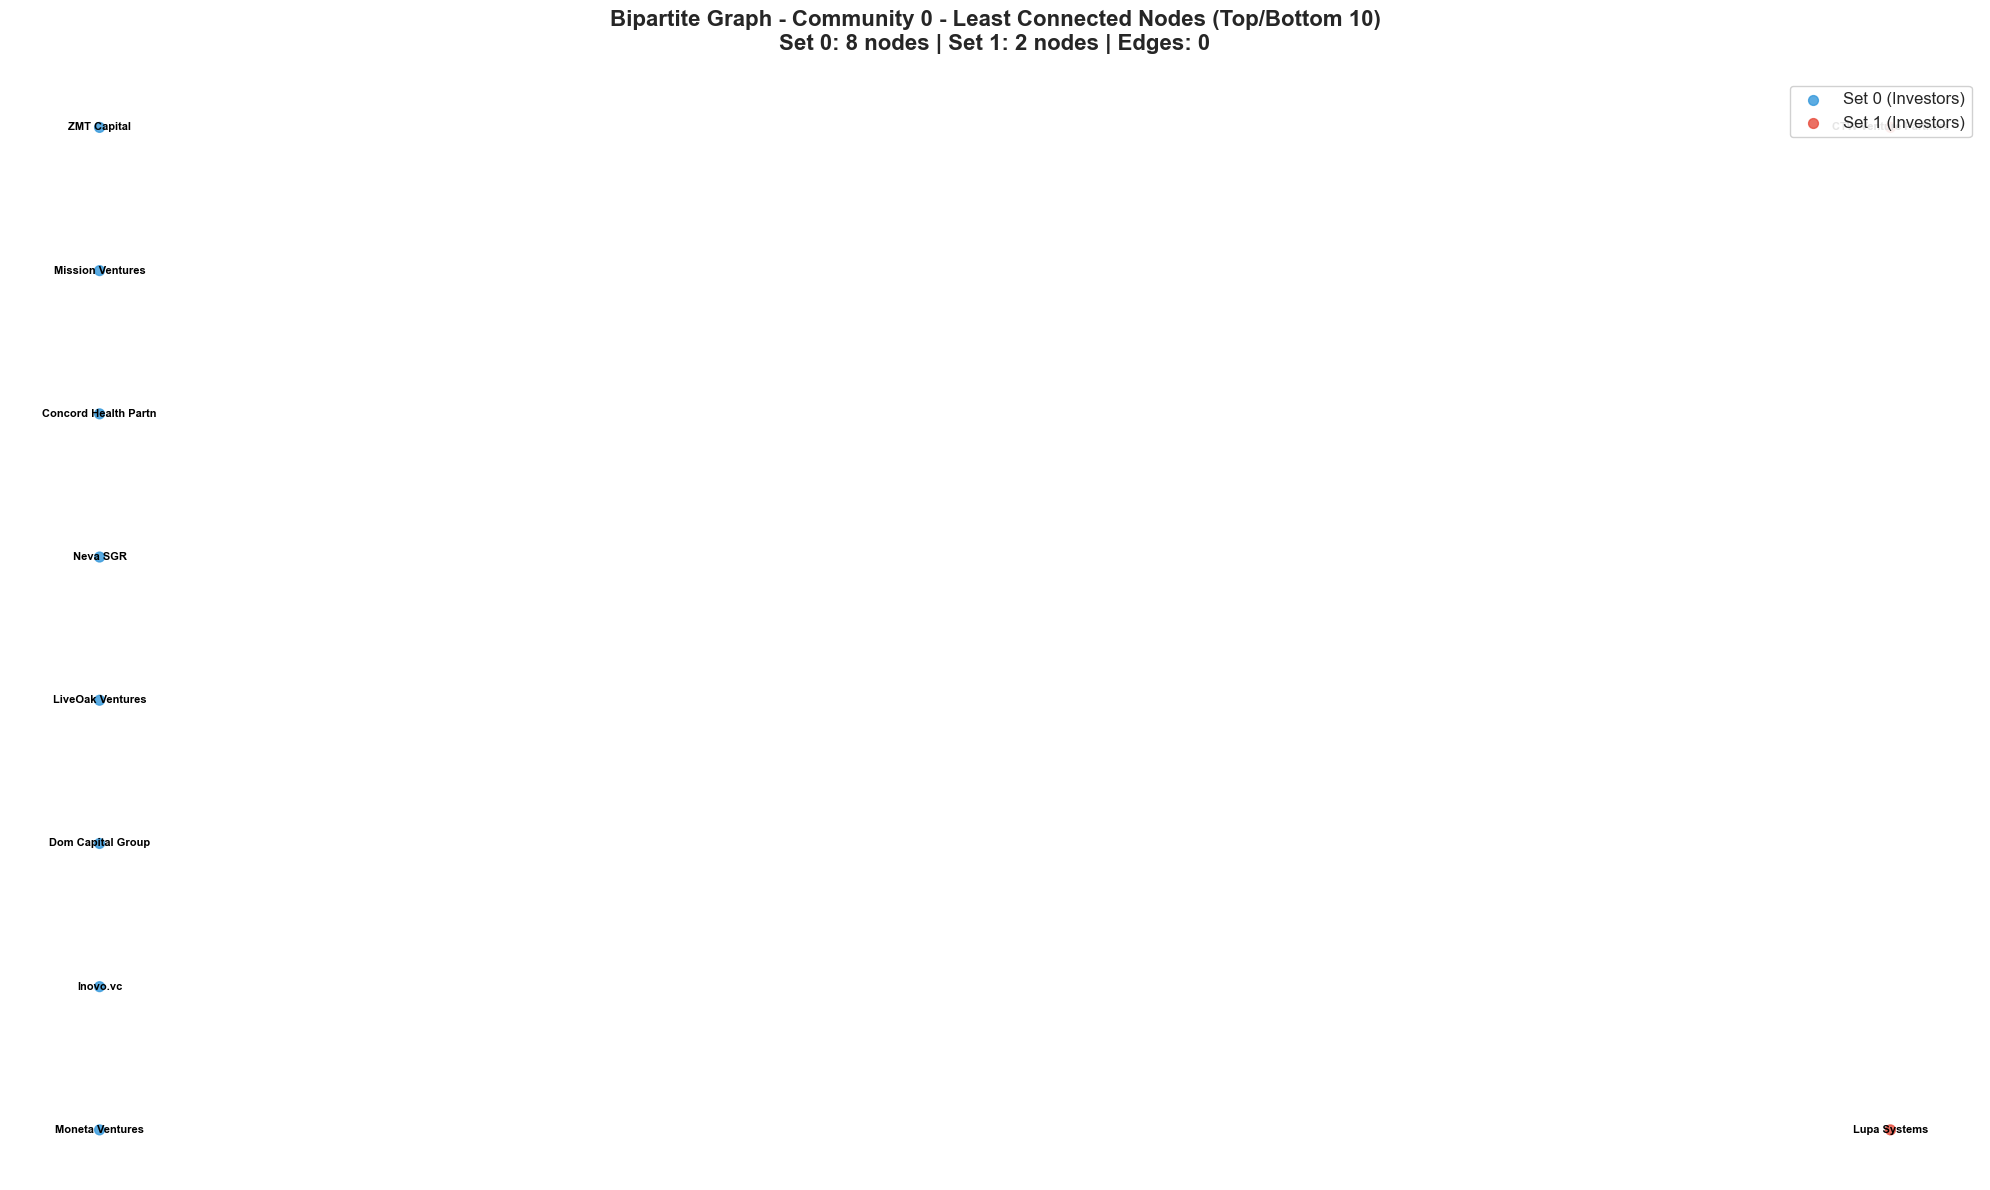




Processing Community 1

Top 10 nodes - Set distribution: Set 0: 4, Set 1: 6
Edges between top nodes: 13

Bottom 10 nodes - Set distribution: Set 0: 9, Set 1: 1
Edges between bottom nodes: 0

--- Most Connected Nodes ---


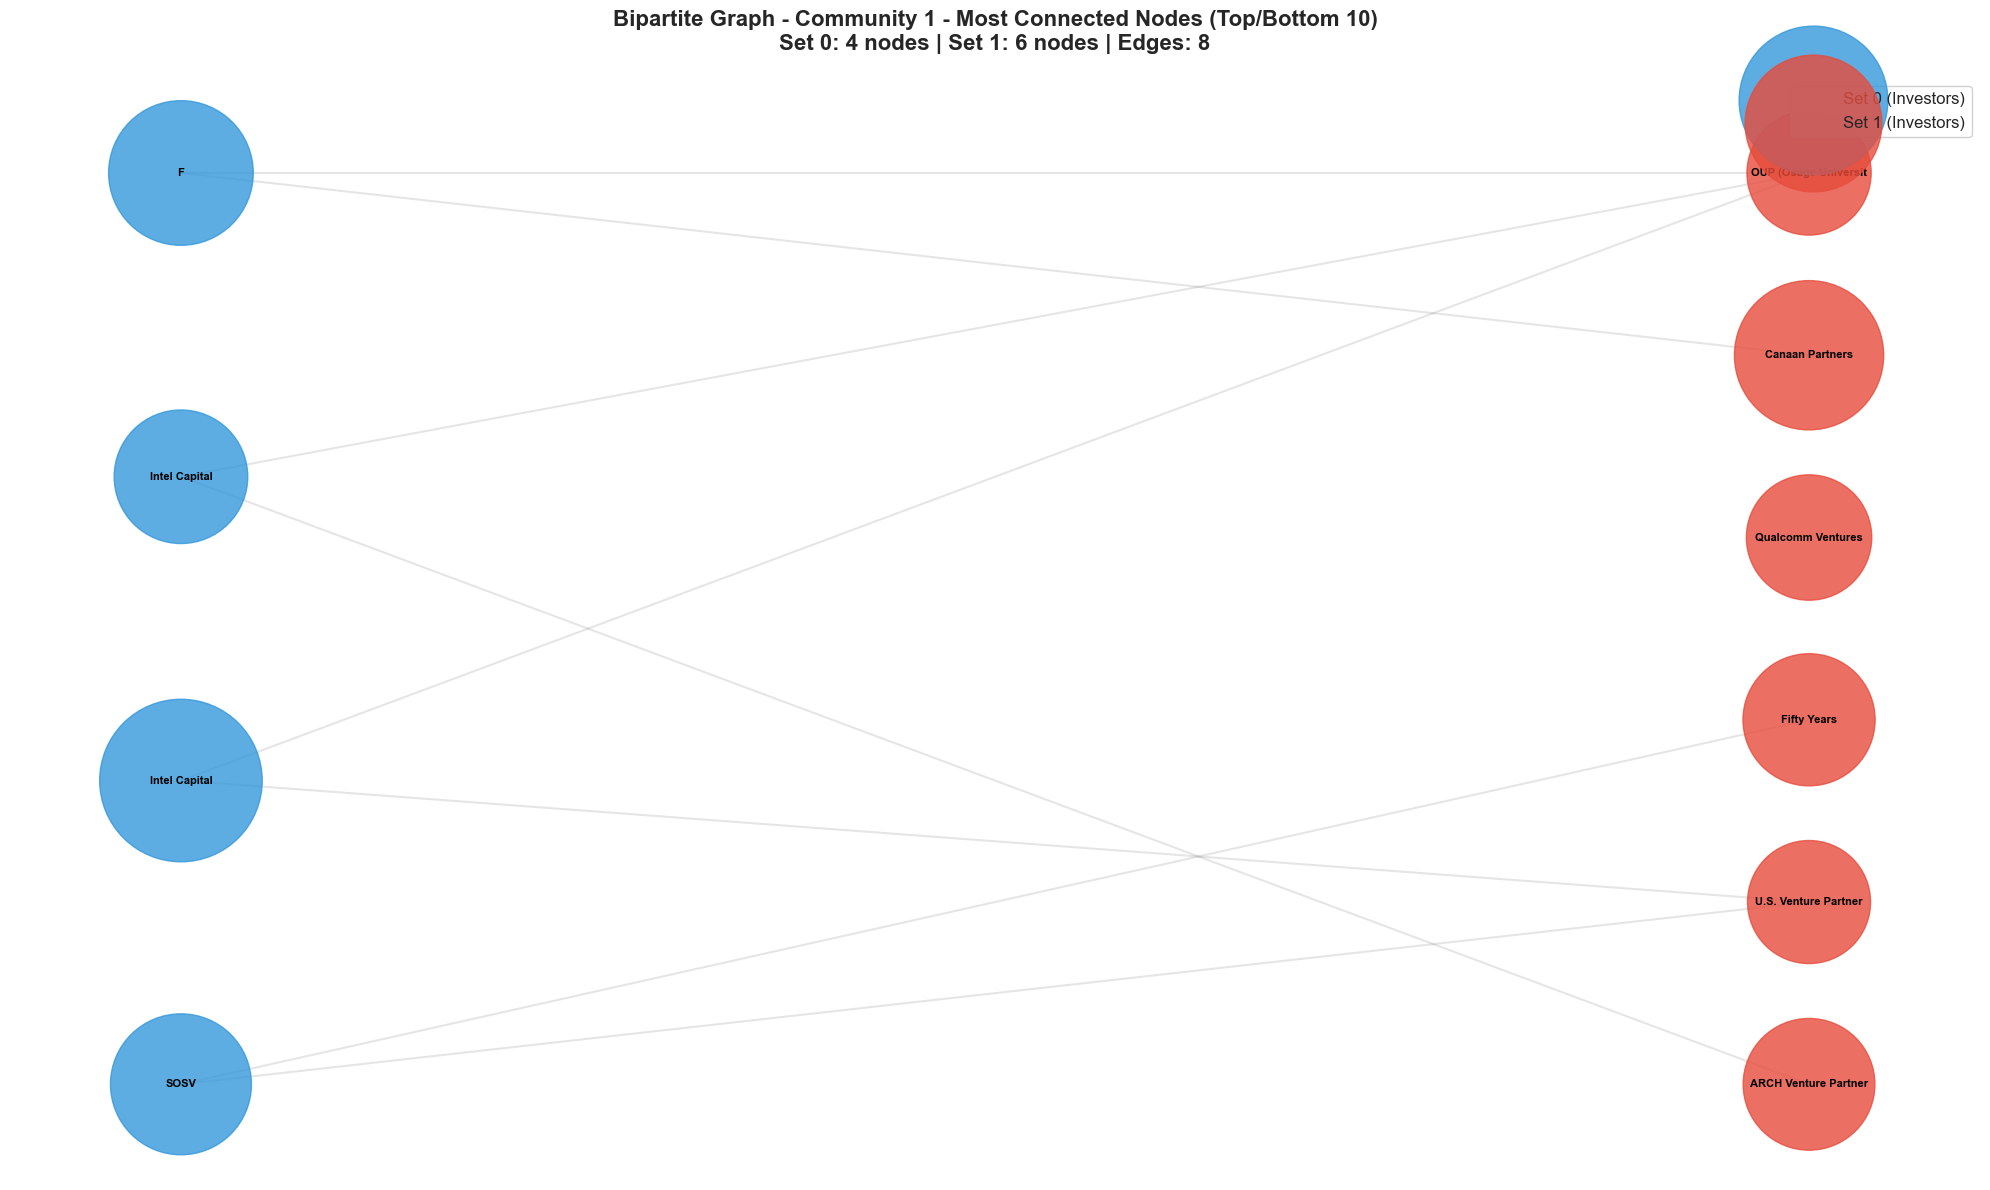


--- Least Connected Nodes ---


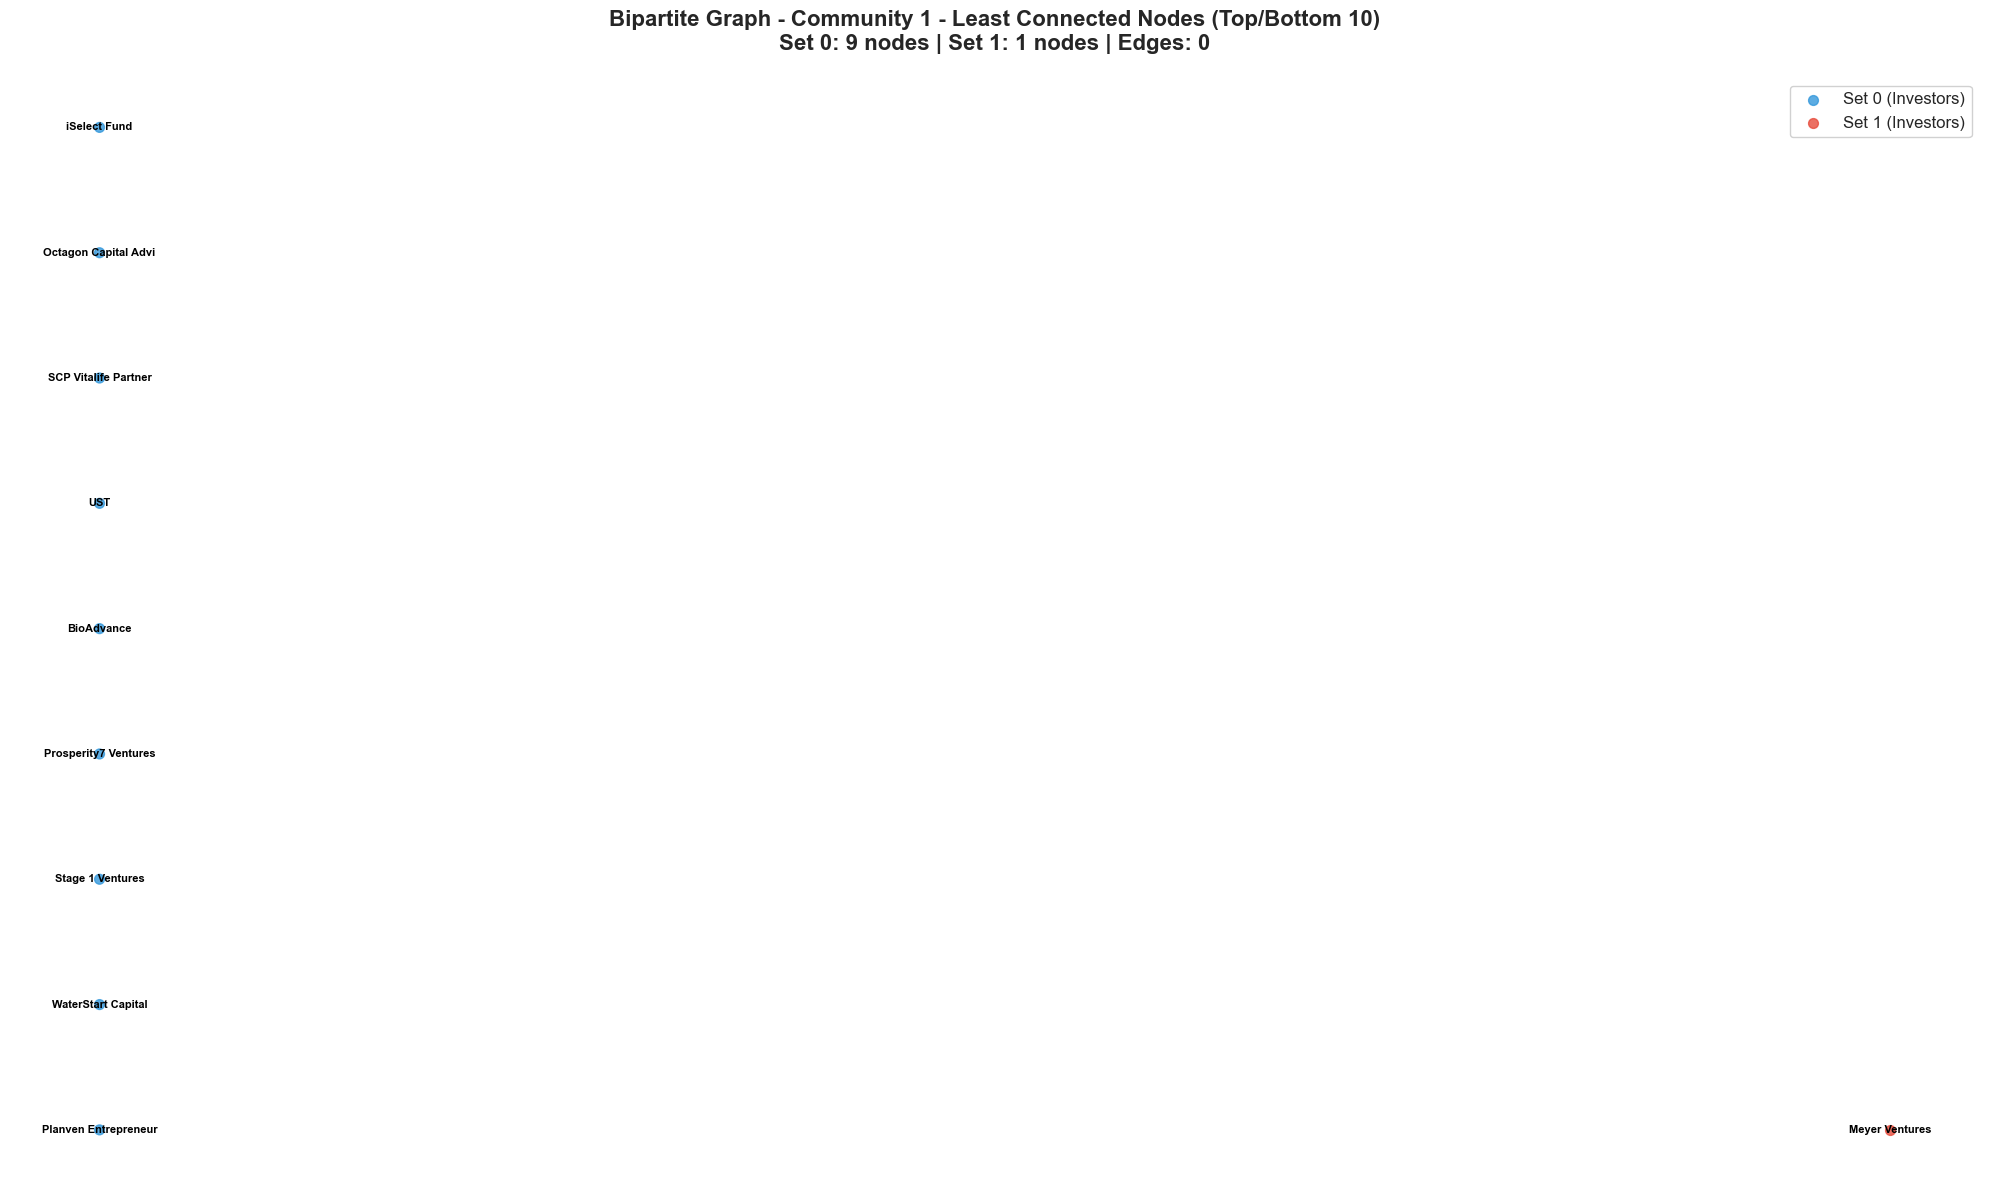




Processing Community 2

Top 10 nodes - Set distribution: Set 0: 2, Set 1: 8
Edges between top nodes: 65

Bottom 10 nodes - Set distribution: Set 0: 6, Set 1: 4
Edges between bottom nodes: 0

--- Most Connected Nodes ---


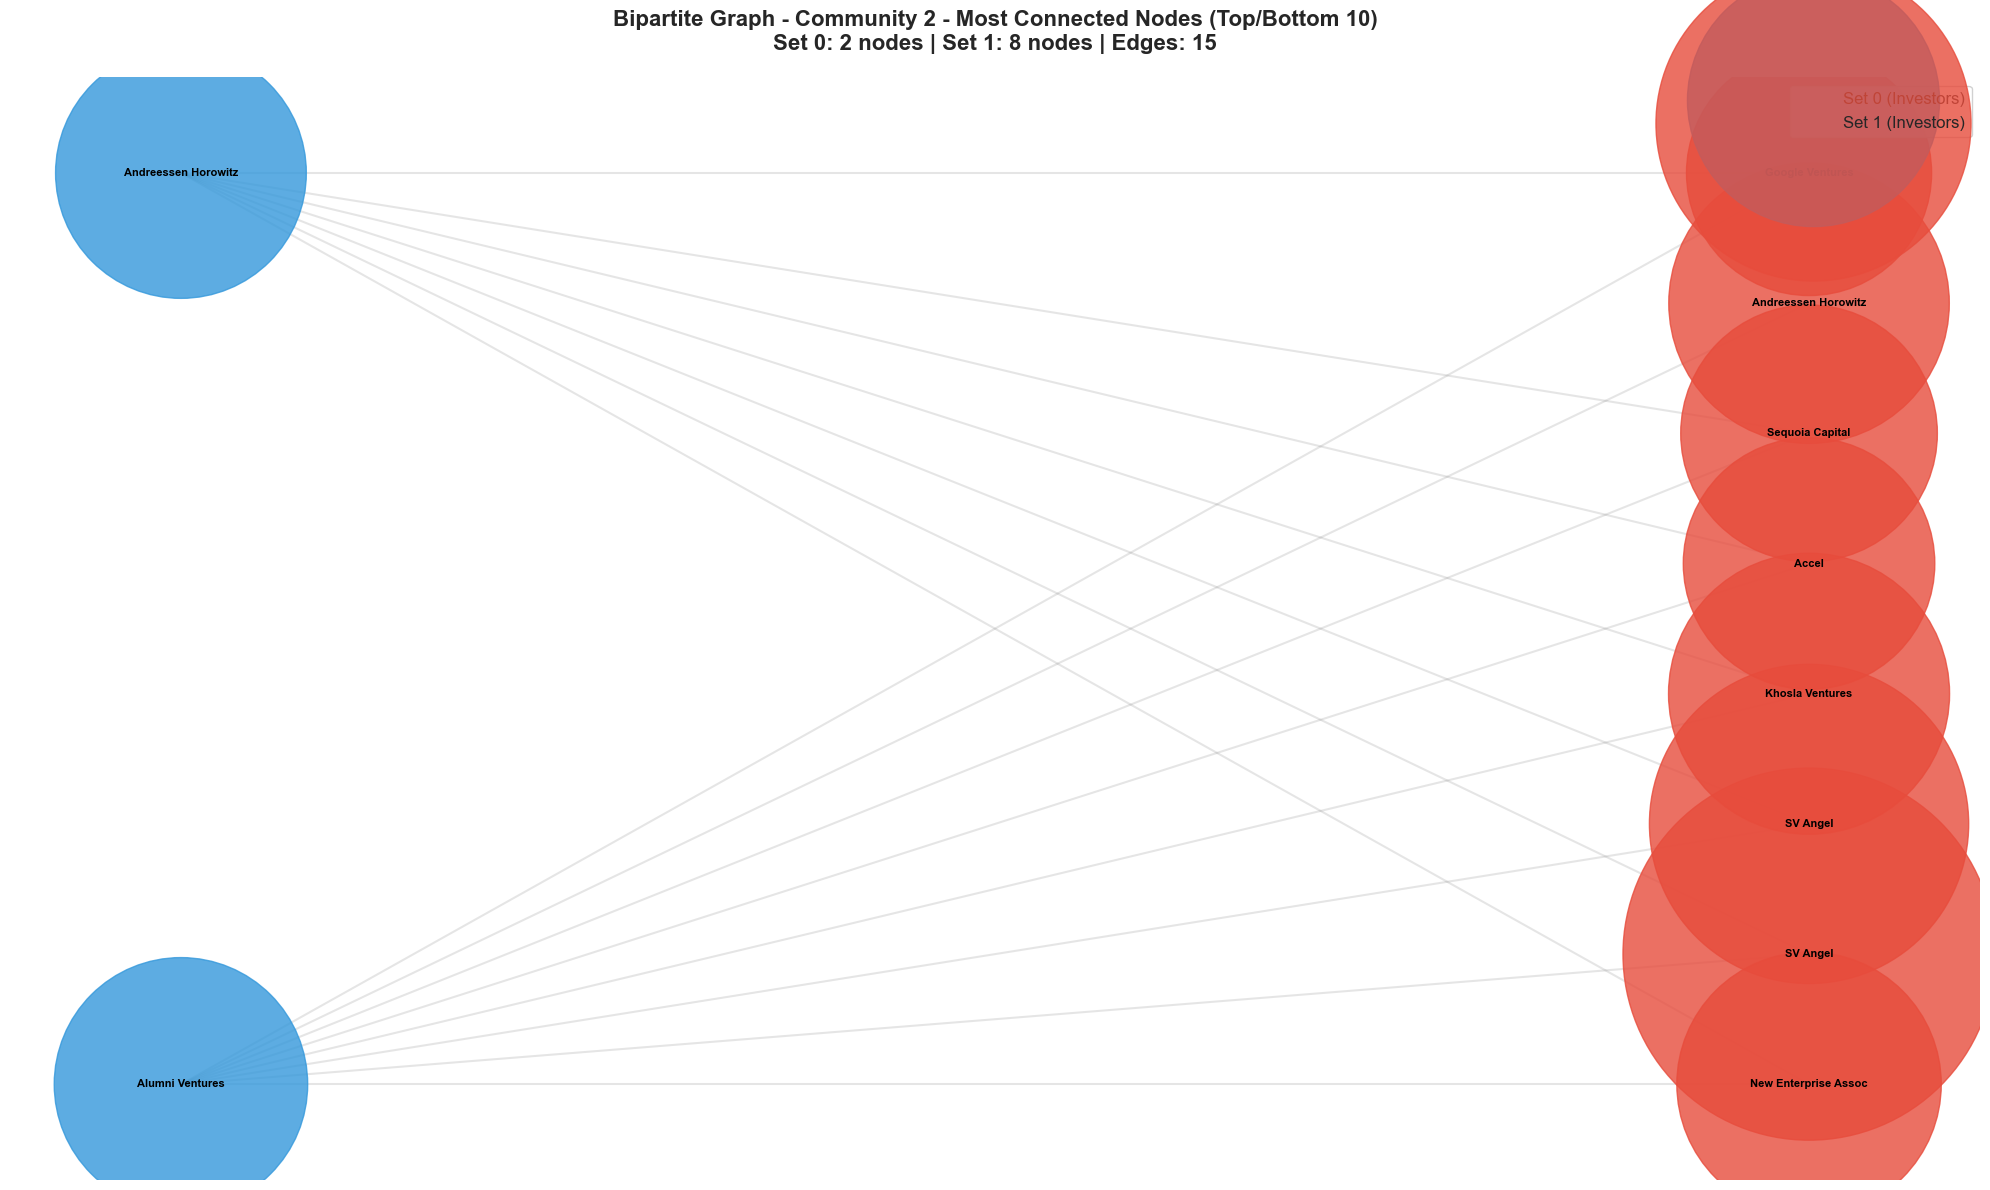


--- Least Connected Nodes ---


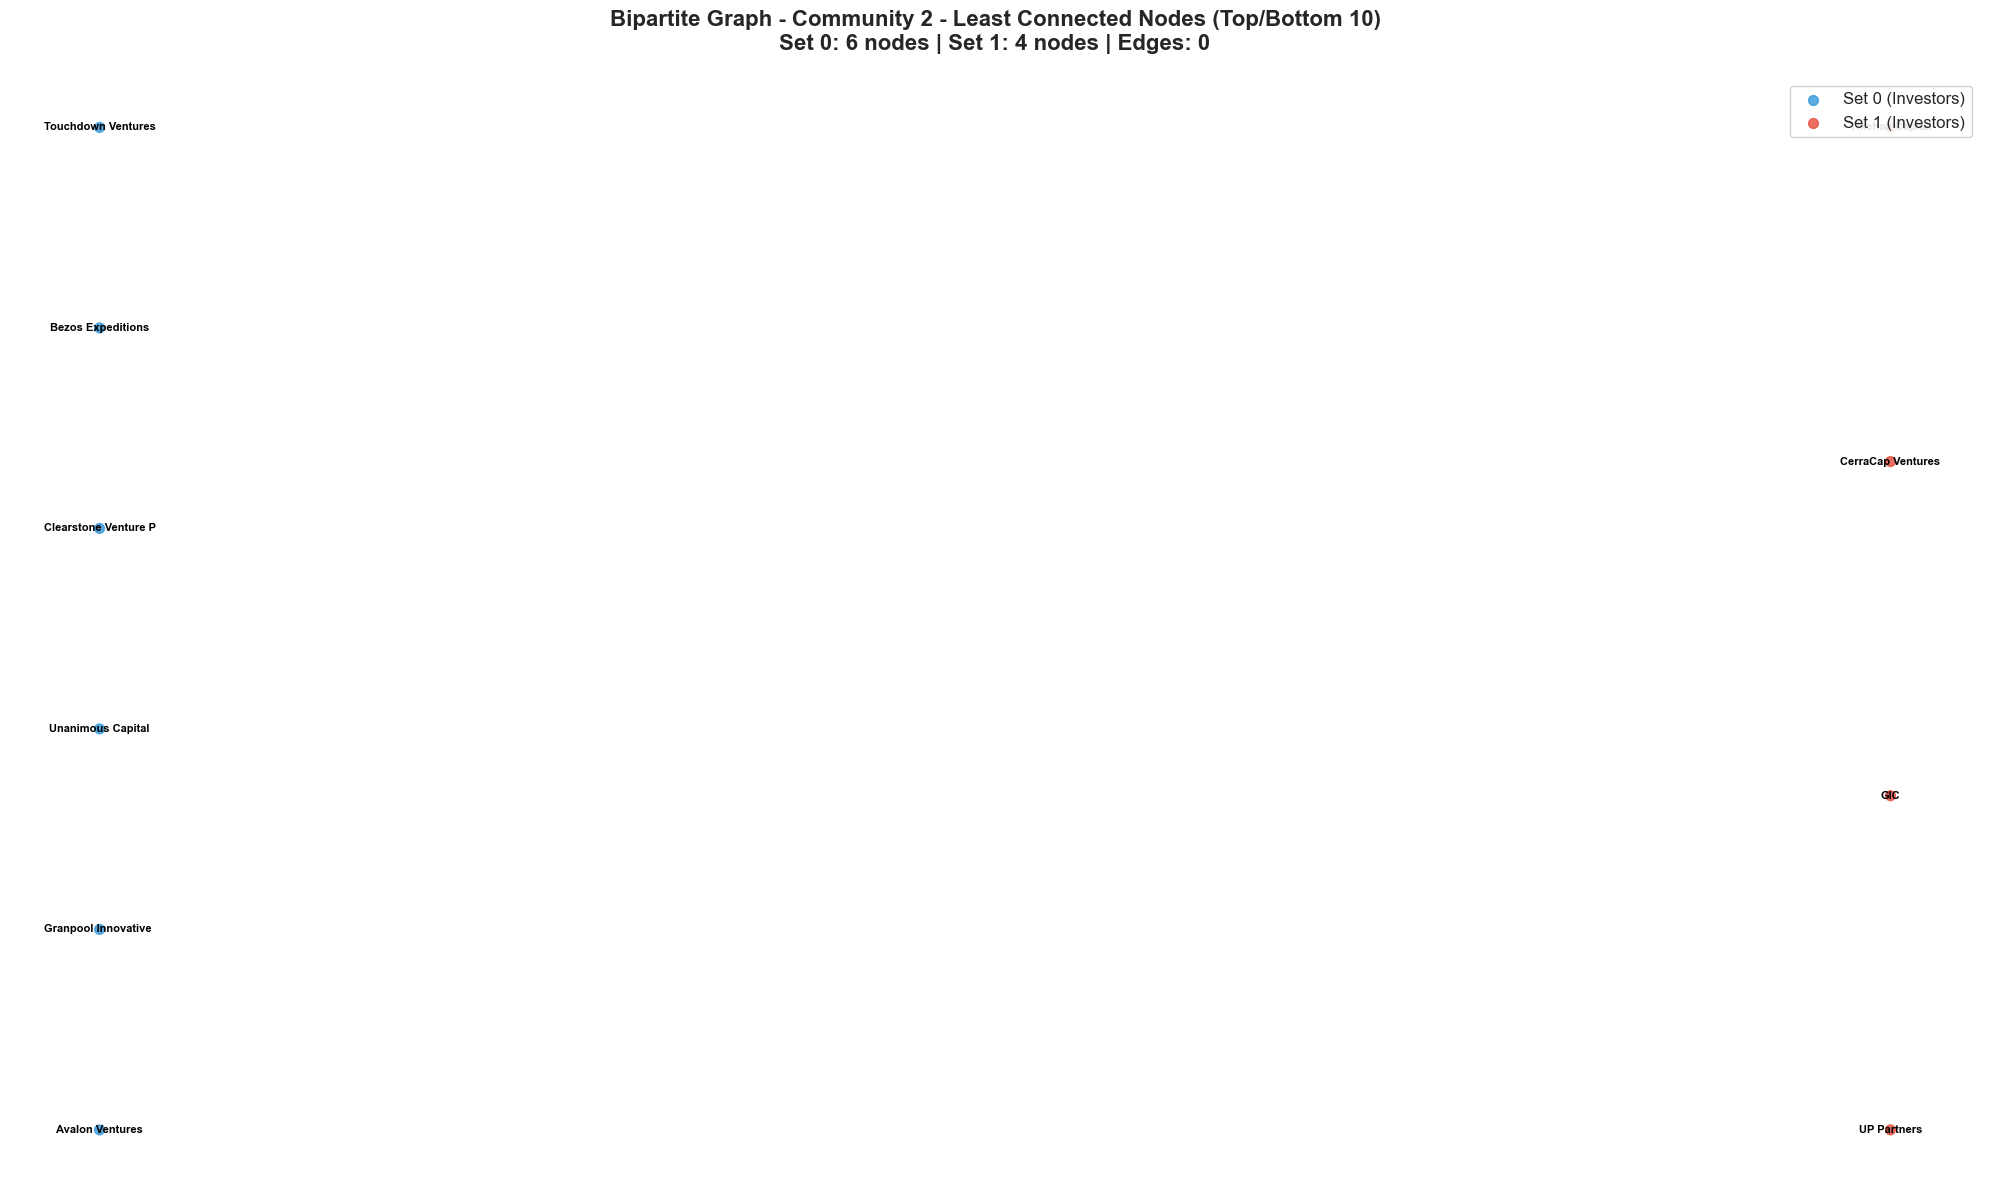




Processing Community 3

Top 10 nodes - Set distribution: Set 0: 1, Set 1: 9
Edges between top nodes: 1

Bottom 10 nodes - Set distribution: Set 0: 9, Set 1: 1
Edges between bottom nodes: 0

--- Most Connected Nodes ---


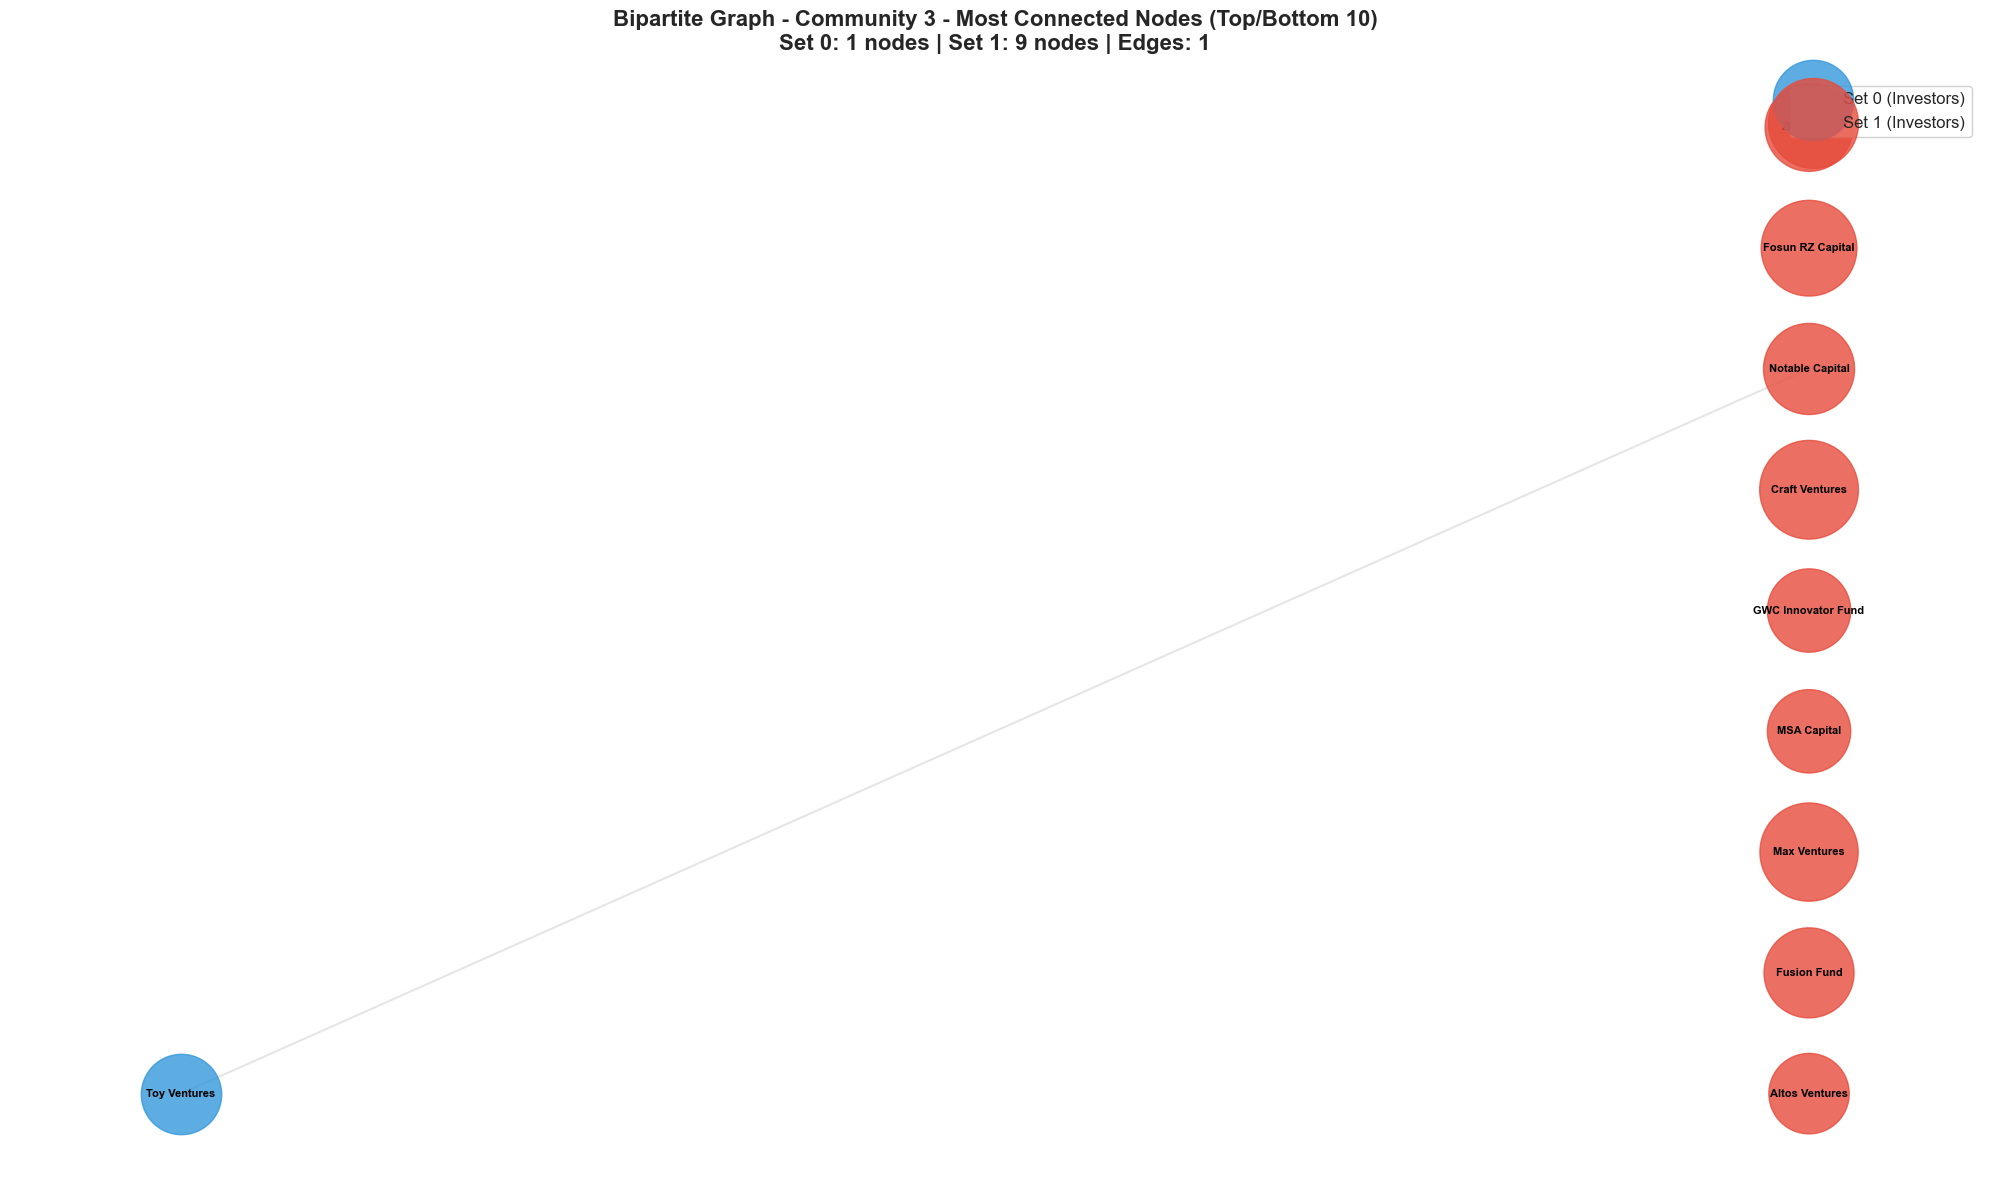


--- Least Connected Nodes ---


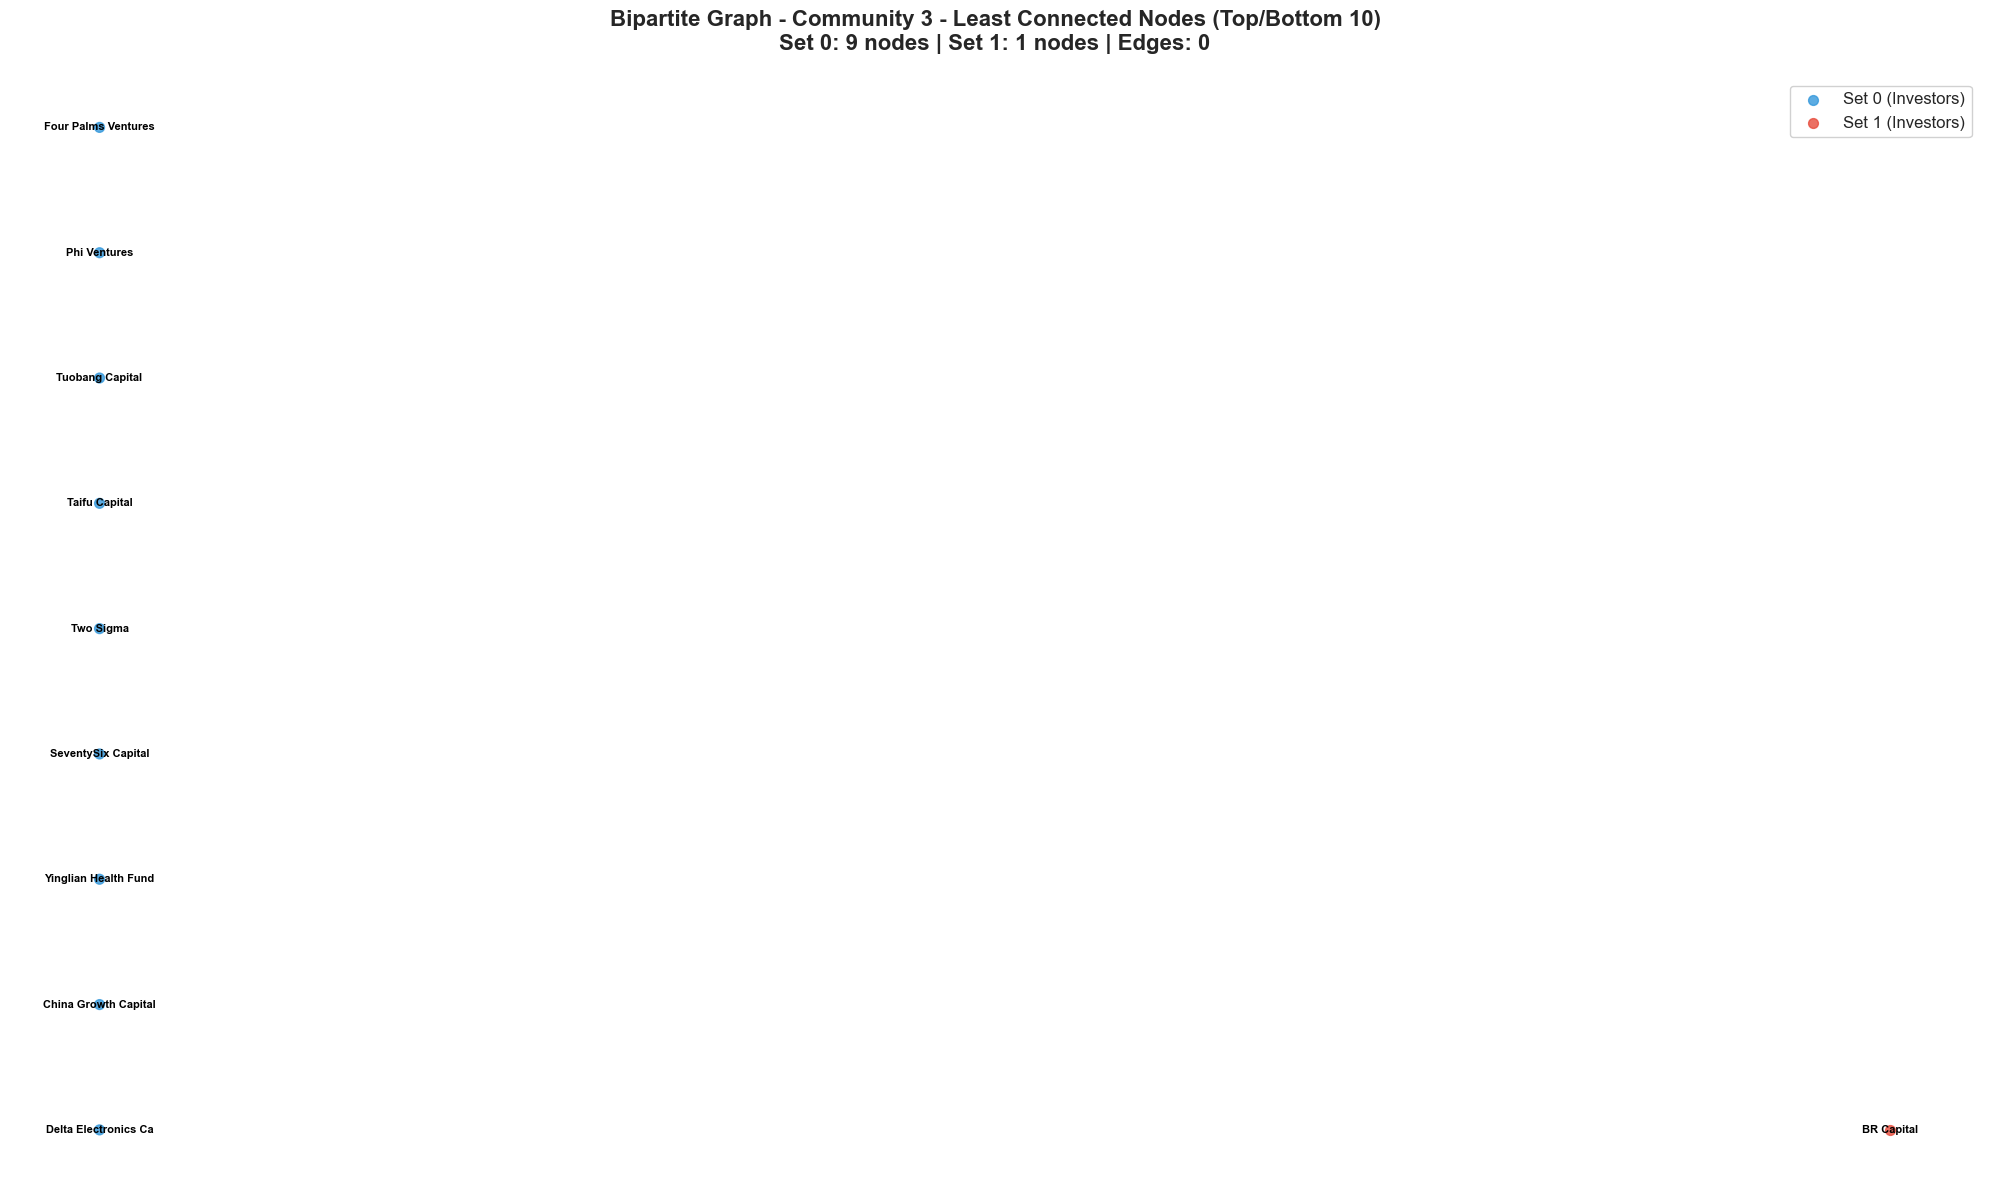




Processing Community 4

Top 10 nodes - Set distribution: Set 0: 5, Set 1: 5
Edges between top nodes: 7

Bottom 10 nodes - Set distribution: Set 0: 7, Set 1: 3
Edges between bottom nodes: 0

--- Most Connected Nodes ---


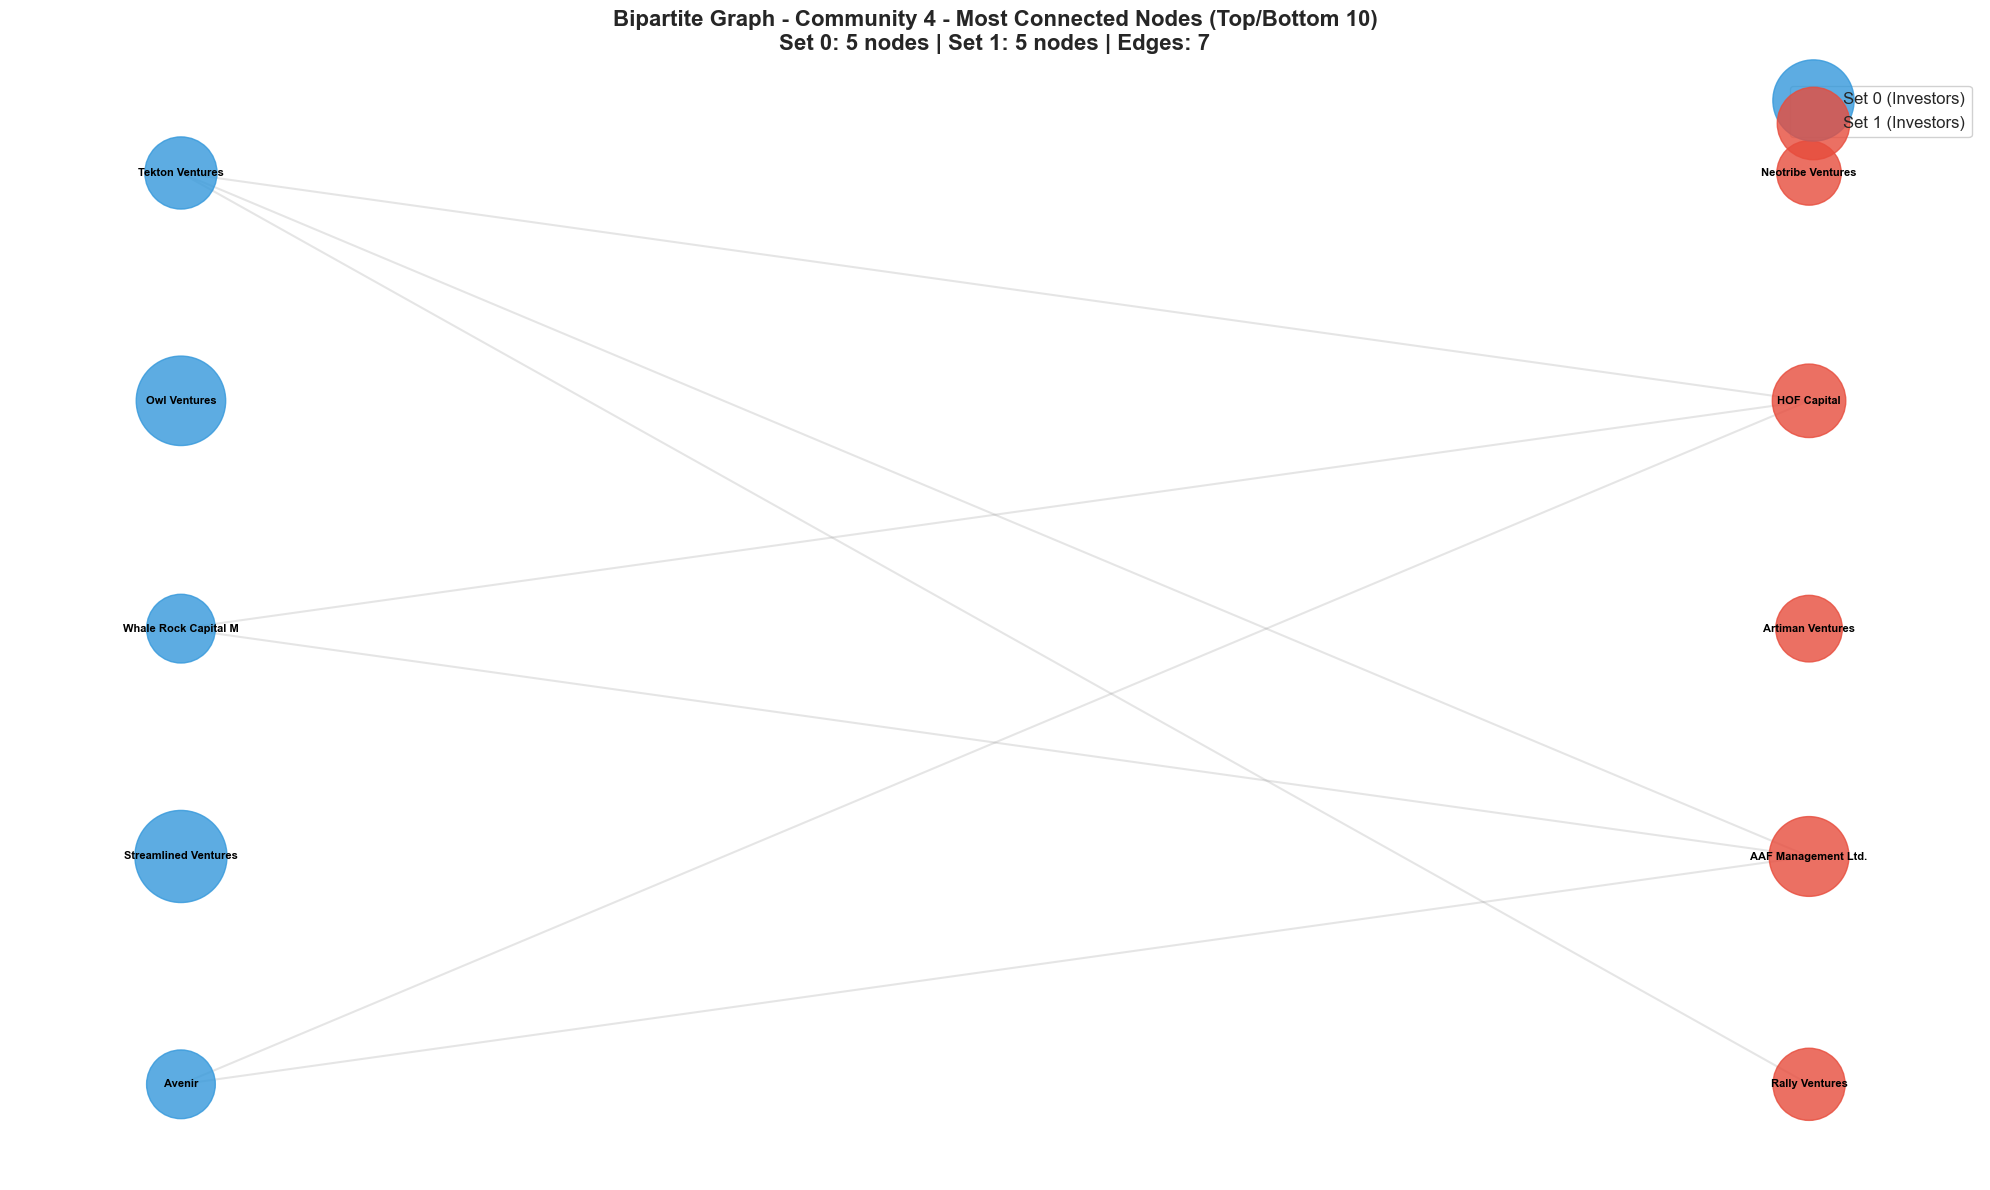


--- Least Connected Nodes ---


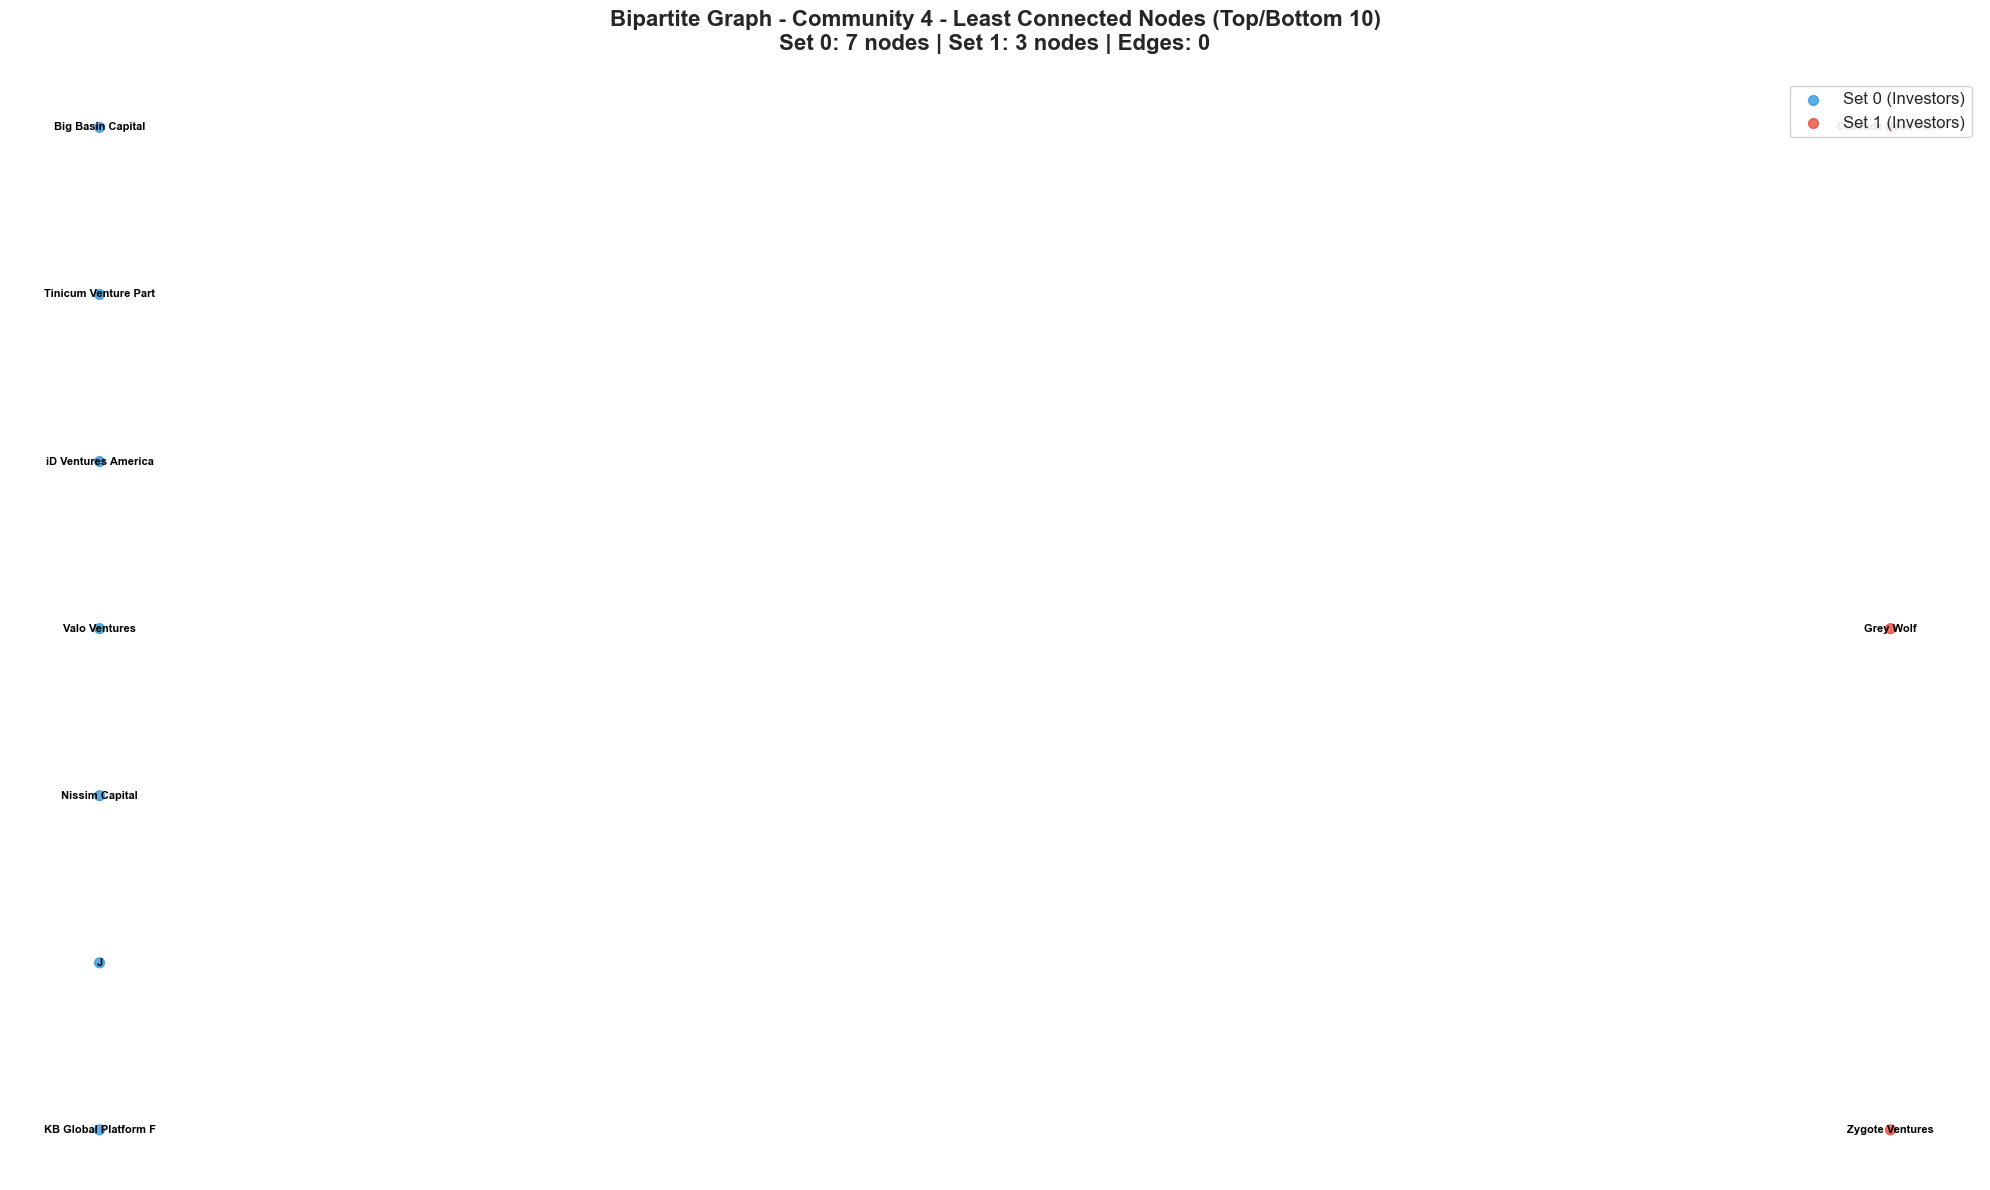

In [ ]:
# Visualize bipartite graphs for communities 0, 1, 2, 3, 4
target_communities = [0, 1, 2, 3, 4]

for community_id in target_communities:
    print(f"\n{'='*100}")
    print(f"Processing Community {community_id}")
    print(f"{'='*100}\n")
    
    # Get top and bottom nodes
    top_nodes, bottom_nodes = get_top_bottom_nodes(nodes_with_degree, community_id, n=10)
    
    # Get edges for these nodes
    top_node_ids = set(top_nodes['node'].values)
    bottom_node_ids = set(bottom_nodes['node'].values)
    
    # Filter edges where both source and target are in our node sets
    top_edges = edges_df[
        (edges_df['Source'].isin(top_node_ids)) & 
        (edges_df['Target'].isin(top_node_ids))
    ]
    
    bottom_edges = edges_df[
        (edges_df['Source'].isin(bottom_node_ids)) & 
        (edges_df['Target'].isin(bottom_node_ids))
    ]
    
    print(f"Top 10 nodes - Set distribution: "
          f"Set 0: {(top_nodes['set'] == 0).sum()}, "
          f"Set 1: {(top_nodes['set'] == 1).sum()}")
    print(f"Degree range: {top_nodes['degree'].min()} - {top_nodes['degree'].max()}")
    print(f"Edges between top nodes: {len(top_edges)}")
    
    print(f"\nBottom 10 nodes - Set distribution: "
          f"Set 0: {(bottom_nodes['set'] == 0).sum()}, "
          f"Set 1: {(bottom_nodes['set'] == 1).sum()}")
    print(f"Degree range: {bottom_nodes['degree'].min()} - {bottom_nodes['degree'].max()}")
    print(f"Edges between bottom nodes: {len(bottom_edges)}")
    
    # Create combined bipartite graph
    print("\n--- Combined: Most and Least Connected Nodes ---")
    g_combined = create_combined_bipartite_graph(top_nodes, bottom_nodes, top_edges, bottom_edges, community_id)
    plt.show()
    
    print("\n")

## Step 4: Detailed Analysis - Node Degree Distribution by Community

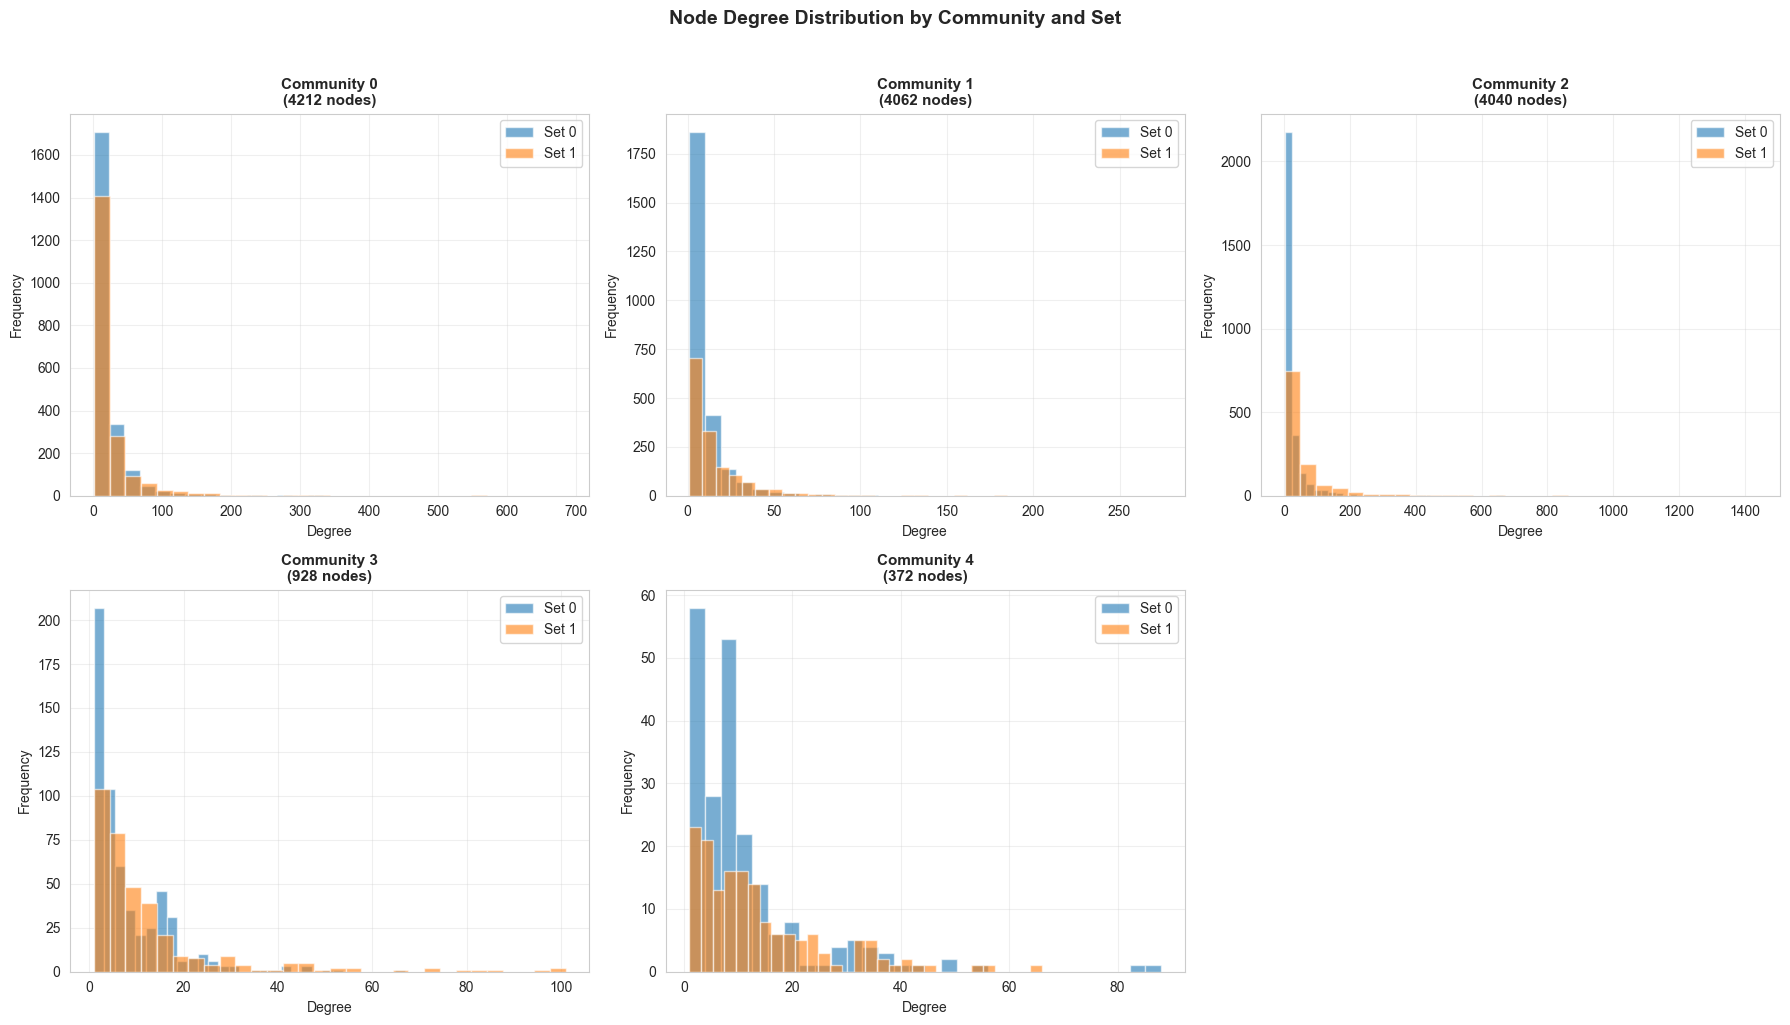

In [19]:
# Visualize degree distribution for communities 0-4
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, community_id in enumerate(target_communities):
    community_data = nodes_with_degree[nodes_with_degree['community_id'] == community_id]
    
    ax = axes[idx]
    
    # Plot degree distribution by set
    for set_val in [0, 1]:
        set_data = community_data[community_data['set'] == set_val]['degree']
        if len(set_data) > 0:
            ax.hist(set_data, bins=30, alpha=0.6, label=f'Set {set_val}')
    
    ax.set_xlabel('Degree', fontsize=10)
    ax.set_ylabel('Frequency', fontsize=10)
    ax.set_title(f'Community {community_id}\n({len(community_data)} nodes)', fontsize=11, fontweight='bold')
    ax.legend()
    ax.grid(alpha=0.3)

# Hide the last subplot
axes[5].axis('off')

plt.suptitle('Node Degree Distribution by Community and Set', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Step 5: Export Results

Save the nodes dataframe with degree information for further analysis.

In [20]:
# Save the nodes dataframe with degree information
output_path = '../data/processed/us/nodes_with_degree.csv'
nodes_with_degree.to_csv(output_path, index=False)
print(f"Saved nodes with degree data to: {output_path}")

# Display final dataframe summary
print(f"\nFinal DataFrame shape: {nodes_with_degree.shape}")
print(f"\nColumns: {nodes_with_degree.columns.tolist()}")
print(f"\nSample of final data:")
print(nodes_with_degree.head(10))

Saved nodes with degree data to: ../data/processed/us/nodes_with_degree.csv

Final DataFrame shape: (15347, 8)

Columns: ['index', 'index.1', 'community_id', 'node', 'community_size', 'id', 'set', 'degree']

Sample of final data:
   index  index.1  community_id                                 node  \
0      0        0             0         Ironspring Ventures-series_a   
1      1        1             0                        Bolt-series_a   
2      2        2             0                 NightDragon-series_e   
3      3        3             0                       Xfund-series_e   
4      4        4             0          Borderless Capital-series_b   
5      5        5             0            Blueprint Equity-series_a   
6      6        6             0  Hyde Park Venture Partners-series_b   
7      7        7             0                 GOS Capital-series_b   
8      8        8             0             Voyager Capital-series_b   
9      9        9             0                 Bu

## Summary

This notebook has completed the following tasks:

1. **Loaded network data** from nodes.csv and edges.csv
2. **Calculated node degrees** by counting connections in the edge list
3. **Created an enriched dataframe** with node information plus degree data
4. **Identified top and bottom 10 nodes** by degree for communities 0, 1, 2, 3, 4
5. **Visualized proper bipartite graphs** for these communities, showing:
   - Most connected nodes (top 10 by degree)
   - Least connected nodes (bottom 10 by degree)
   - Nodes separated by "set" attribute (0 on left, 1 on right)
   - Actual edges/connections between nodes in the network
6. **Analyzed degree distributions** across communities and sets
7. **Exported results** for further analysis

The bipartite visualizations show the actual network structure within each community, with nodes positioned by their set membership (using bipartite layout), sized by their degree, and edges showing the actual connections between investors.